# Diputrax V11 — Verificaciones empíricas y modelos alternativos en respuesta a las Observaciones 2, 3 y 4

**Naturaleza de este cuaderno.** Este notebook es una **adición** a `diputraxv10.ipynb`; **no reemplaza ni modifica** ninguna celda, target ni modelo del cuaderno principal. Su único objeto es **atender las Observaciones 2, 3 y 4** del dictamen del lector, aportando (a) las **verificaciones empíricas** que el texto no reportaba y (b) los **modelos alternativos** que las observaciones proponen, **desarrollados por completo** —con la misma profundidad que v10: comparación multi-modelo, interpretación SHAP, estabilidad de la validación cruzada, capa inferencial bayesiana y evaluación de desempeño con sus gráficos y tablas.

> **La Observación 1** (marco normativo JUCOPO / proporcionalidad) **queda deliberadamente fuera de este cuaderno**: se resuelve con texto expositivo en §1.1 y §3.1 de la tesis y no requiere ningún modelo. Se excluye por instrucción explícita.

**Cómo leer cada sección.** Cada observación se presenta en tres bloques: `▸ Observación` (lo que el lector señala), `▸ Respuesta` (cómo la atendemos) y `▸ Verificación empírica` (el código, sus gráficos y sus resultados). Los recuadros marcados **Respuesta a la Observación N** indican de forma inequívoca a qué observación responde cada resultado.

**Ejecución secuencial.** El cuaderno replica de forma **idéntica y autocontenida** el pipeline de `diputraxv10` (imputación MICE → feature engineering → `LogisticRegression` L1 + `SelectFromModel`, CV estratificada *k*=5). Corre de principio a fin sin depender de v10 en tiempo de ejecución, pero reproduce exactamente su infraestructura para que los modelos nuevos sean **comparables celda a celda** con los de la tesis. La sección 0 reconstruye ese pipeline; a partir de la sección 1 se añaden únicamente los modelos nuevos, cada uno desarrollado al mismo nivel de detalle que los targets originales de la tesis.

**Nota de entorno.** El desarrollo de los modelos usa `LogisticRegression` (L2 y L1/Lasso), `RandomForestClassifier` y la interpretación `shap`, todos disponibles en el kernel `diputrax`. XGBoost —una de las cinco columnas de la Tabla 7 de v10— se **omite** de las tablas comparativas de este cuaderno únicamente porque el paquete no está instalado en el entorno de ejecución de v11; su ausencia no afecta ninguna conclusión, pues el modelo principal de la tesis es `LR L1 + SFM`, presente en todas las tablas.

**Compatibilidad.** Las tres observaciones resultaron **compatibles** con el diseño de v10: ninguna obliga a remodelar el cuerpo principal, y las verificaciones confirman que las conclusiones de la tesis son robustas. Por ello **no se generó** un cuaderno alternativo `diputraxv11alter.ipynb`; toda la evidencia cabe como extensión aditiva en este archivo (véase la nota de cierre).

# 0. Infraestructura replicada de diputraxv10

Réplica **verbatim** del pipeline de v10 (celdas 69–78 de `diputraxv10.ipynb`): mismas constantes de era, misma imputación MICE, mismo feature engineering, mismas *model factories* y misma validación cruzada. Se añaden únicamente **cuatro targets nuevos** —`pres_bin`, `lider_bin`, `cat4`— derivados de columnas que ya existen en el parquet, sin tocar los targets originales `nodal_bin`, `lastre_bin` ni `n_comisiones_tematicas`, y las utilidades de gráfico/SHAP/bayesiano necesarias para desarrollarlos al nivel de v10.

In [1]:
import warnings, io, logging
warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score, cross_val_predict,
)
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, f1_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
import shap

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)
print("Imports OK  |  shap", shap.__version__)

Imports OK  |  shap 0.52.0


In [2]:
# --- Constantes idénticas a v10 (celda 70) ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET = PROJECT_ROOT / "data" / "clean" / "diputados_20260421_205712.parquet"
REPORT_DIR = PROJECT_ROOT / "reports" / "eda"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

ERA_MAP = {
    57: "ERA_1_PRI",  58: "ERA_1_PRI",  59: "ERA_1_PRI",
    60: "ERA_2_PAN",  61: "ERA_2_PAN",  62: "ERA_2_PAN",
    63: "ERA_3_TRANS", 64: "ERA_3_TRANS", 65: "ERA_3_TRANS",
    66: "ERA_4_MORENA",
}
ERA_ORDER = ["ERA_1_PRI", "ERA_2_PAN", "ERA_3_TRANS", "ERA_4_MORENA"]
ERA_LABELS = {
    "ERA_1_PRI":    "ERA 1 — PRI (57-59)",
    "ERA_2_PAN":    "ERA 2 — PAN (60-62)",
    "ERA_3_TRANS":  "ERA 3 — Transicion (63-65)",
    "ERA_4_MORENA": "ERA 4 — Morena (66)",
}
ERA_COLORS = {
    "ERA_1_PRI": "#c0392b", "ERA_2_PAN": "#2980b9",
    "ERA_3_TRANS": "#8e44ad", "ERA_4_MORENA": "#27ae60",
}
TOP_PARTIDOS = ["PRI", "PAN", "MORENA", "PRD", "PVEM", "PT", "MC"]

raw = pd.read_parquet(PARQUET)
print(f"Shape: {raw.shape}")

Shape: (5000, 79)


In [3]:
# --- MICE idéntico a v10 (celda 74) ---
_MICE_COND_VARS = [
    'legislatura_num', 'n_cargos_legislativos_prev',
    'fue_diputado_local', 'fue_diputado_federal', 'fue_senador',
    'n_trayectoria_legislativa', 'n_trayectoria_admin', 'nivel_cargo_max',
    'fue_presidente_mun', 'fue_secretario_cargo', 'fue_director_general',
    'fue_subsecretario', 'admin_en_gobierno_fed', 'admin_en_gobierno_est',
    'admin_en_gobierno_mun', 'edad_al_tomar_cargo',
]
_mice_cols = [c for c in _MICE_COND_VARS if c in raw.columns]
_mice_imputer = IterativeImputer(max_iter=10, random_state=42,
                                 initial_strategy='mean', skip_complete=True)
_mice_df = pd.DataFrame(_mice_imputer.fit_transform(raw[_mice_cols].copy()),
                        columns=_mice_cols, index=raw.index)

raw['edad_missing'] = raw['edad_al_tomar_cargo'].isna().astype(int)
raw['edad_imp'] = np.where(
    raw['edad_al_tomar_cargo'].isna(),
    _mice_df['edad_al_tomar_cargo'].clip(18, 90),
    raw['edad_al_tomar_cargo'],
)
print(f"MICE OK — N imputados: {int(raw['edad_missing'].sum())}, "
      f"media edad_imp: {raw['edad_imp'].mean():.2f}")

MICE OK — N imputados: 510, media edad_imp: 45.98


In [4]:
# --- Feature engineering idéntico a v10 (celda 75) + targets nuevos v11 ---
df = raw.copy()
df["era"] = df["legislatura_num"].map(ERA_MAP)

# Targets ORIGINALES de la tesis (idénticos a v10, intactos)
df["nodal_bin"]  = (df["n_comisiones_nodales"] >= 1).astype(int)
df["lastre_bin"] = (df["n_comisiones_lastre"]  >= 1).astype(int)

# ------------------------------------------------------------------
# TARGETS NUEVOS v11 (derivados de columnas ya existentes en el parquet)
# ------------------------------------------------------------------
# OBS 2 y 3 — mesa directiva:
df["pres_bin"]  = (df["presidente_comision"] > 0).astype(int)   # ≥1 presidencia
df["lider_bin"] = (df["lider_comision"]      > 0).astype(int)   # presidente O secretario
# OBS 4 — categoría mutuamente excluyente: 0=ninguna,1=solo nodal,2=solo lastre,3=ambas
df["cat4"] = df["nodal_bin"] + 2 * df["lastre_bin"]

# Region, partido, univ_elite, sexo (idéntico v10)
REGION_MAP = {
    "CDMX": "CDMX",
    **dict.fromkeys(["MEX","HGO","MOR","PUE","TLAX","QRO","GTO","AGS"], "CENTRO"),
    **dict.fromkeys(["VER","OAX","CHIS","TAB","GRO","CAM","YUC","QROO"], "SUR"),
    **dict.fromkeys(["NL","TAMPS","COAH","CHIH","SON","BC","BCS","SIN",
                     "DGO","ZAC","SLP","NAY"], "NORTE"),
    **dict.fromkeys(["JAL","COL","MICH"], "OCCIDENTE"),
    "DESCONOCIDO": "RP",
}
df["region"]      = df["entidad_codigo"].map(REGION_MAP).fillna("CENTRO")
df["partido_cat"] = df["partido"].where(df["partido"].isin(TOP_PARTIDOS), "OTRO")
df["univ_elite"]  = df[["acad_unam","acad_itam","acad_ibero","acad_itesm"]].max(axis=1)
df["sexo_bin"]    = (df["sexo"] == "M").astype(int)

_p    = pd.get_dummies(df["partido_cat"],    prefix="p")
_reg  = pd.get_dummies(df["region"],         prefix="reg")
_area = pd.get_dummies(df["area_formacion"], prefix="area")
df_enc = pd.concat([df, _p, _reg, _area], axis=1)

print("Feature engineering OK")
print("\nTasas de los targets nuevos por era:")
display(df.groupby("era")[["nodal_bin","lastre_bin","pres_bin","lider_bin"]]
          .mean().reindex(ERA_ORDER).round(3))

Feature engineering OK

Tasas de los targets nuevos por era:


,nodal_bin,lastre_bin,pres_bin,lider_bin
era,,,,
ERA_1_PRI,0.322,0.421,0.151,0.570
ERA_2_PAN,0.407,0.459,0.215,0.861
ERA_3_TRANS,0.495,0.499,0.172,0.971
ERA_4_MORENA,0.554,0.392,0.114,0.980


In [5]:
# --- Espacio de features idéntico a v10 (celda 76) ---
NUMERIC_FEATS = [
    "sexo_bin", "edad_imp", "edad_missing",
    "mayoria_relativa", "es_partido_mayoria", "legislatura_num",
    "grado_estudios_ord", "tiene_posgrado", "tiene_doctorado",
    "estudios_en_extranjero", "univ_publica", "univ_privada",  # AC1(v0): univ_extranjera eliminada — duplicado exacto (r=1.0)
    "univ_elite",
    # AC1(v0): n_cargos_legislativos_prev eliminada — = fue_diputado_local+fue_diputado_federal+fue_senador (combinacion lineal exacta)
    "fue_diputado_local",
    "fue_diputado_federal", "fue_senador", "n_trayectoria_legislativa",
    "n_trayectoria_admin", "nivel_cargo_max",
    "fue_presidente_mun", "fue_presidente_org", "fue_director_general",
    "fue_secretario_cargo", "fue_subsecretario", "fue_director",
    "fue_coordinador", "fue_delegado", "fue_asesor", "fue_regidor", "fue_sindico",
    "admin_en_partido", "admin_en_sindicato", "admin_en_universidad",
    "admin_en_gobierno_fed", "admin_en_gobierno_est", "admin_en_gobierno_mun",
    "n_trayectoria_politica", "tiene_exp_juvenil",
    "lider_juvenil_partido", "lider_juvenil_gobierno", "miembro_org_juvenil",
    "nivel_liderazgo_juvenil",
    "n_trayectoria_empresarial", "n_investigacion_docencia", "n_organos_gobierno",
]
_AREA_KEEP = ["area_Derecho", "area_Ciencias Políticas y Sociales",
              "area_Económico-Financiera"]
DUMMY_FEATS = list(_p.columns) + list(_reg.columns) + \
              [c for c in _AREA_KEEP if c in df_enc.columns]
FEAT_COLS = NUMERIC_FEATS + DUMMY_FEATS

# Importante: n_presidencias / n_secretarias NO están en FEAT_COLS, de modo que
# no hay fuga (leakage) hacia los targets de mesa directiva. Verificación:
assert "n_presidencias" not in FEAT_COLS and "n_secretarias" not in FEAT_COLS
assert "presidente_comision" not in FEAT_COLS and "lider_comision" not in FEAT_COLS
print(f"Features totales: {len(FEAT_COLS)}  "
      f"(numéricas={len(NUMERIC_FEATS)}, dummies={len(DUMMY_FEATS)})")

Features totales: 64  (numéricas=47, dummies=17)


## Acciones correctivas (derivadas de diputraxv0)

Se propagan a este cuaderno las acciones correctivas aplicadas en diputraxv10, derivadas del diagnóstico de supuestos de `diputraxv0` (§8 y §12):

- **AC1 — Consolidación de features redundantes.** Se elimina `univ_extranjera` (duplicado exacto de `estudios_en_extranjero`, r=1.0) y `n_cargos_legislativos_prev` (suma exacta de `fue_diputado_local + fue_diputado_federal + fue_senador`, ya incluidos). Son redundancias *dentro del espacio-columna*: el AUC/MAE es invariante a su eliminación; solo se depura la atribución SHAP y los VIF.
- **AC2 — Validación sin fuga por reelección.** Se añaden `get_groups()` (por `diputado_id`) y `cv_auc_grouped` / `cv_mae_grouped` (`StratifiedGroupKFold` / `GroupKFold`) para estimar el desempeño sin que un mismo diputado reelecto quede en train y test del mismo fold.

**No aplica aquí:** AC1b (reindexado de `KEY_FEATS`) — v11 usa `KEY_FEATS` dinámico (`df_imp_p.index[:6]`), no hay lista fija que reindexar.

**Límite interpretativo (v0 §6, §8):** en eras de partido dominante `es_partido_mayoria` es casi colineal con la identidad partidista (VIF≈129 en ERA_4); su lectura debe ser asociativa, no causal.

In [ ]:
# ============================================================
# VERIFICACION de acciones correctivas (AC1 + AC2)
# Mide el antes/después sobre el modelo productivo LR-L1.
# ============================================================
_REDUND = ["univ_extranjera", "n_cargos_legislativos_prev"]  # eliminadas por AC1
_rows = []
for _t in ["nodal_bin", "lastre_bin"]:
    for _era in ERA_ORDER:
        try:
            _X, _y = get_Xy(_era, _t)
            _g = get_groups(_era)
            _mask = df_enc["era"] == _era
            _extra = [c for c in _REDUND if c in df_enc.columns and c not in _X.columns]
            _X_old = pd.concat([_X, df_enc.loc[_mask, _extra].astype(float).reset_index(drop=True)], axis=1)
            auc_clean, _ = cv_auc(lr_binary(), _X, _y)
            auc_redun, _ = cv_auc(lr_binary(), _X_old, _y)
            auc_group, _ = cv_auc_grouped(lr_binary(), _X, _y, _g)
            _rows.append({"target": _t, "era": _era,
                          "AUC pre-AC1": round(auc_redun, 4),
                          "AUC post-AC1": round(auc_clean, 4),
                          "D AC1": round(auc_clean - auc_redun, 4),
                          "AUC AC2 (GroupKFold)": round(auc_group, 4),
                          "D AC2": round(auc_group - auc_clean, 4)})
        except Exception as _e:
            _rows.append({"target": _t, "era": _era, "error": str(_e)})
print(f"FEAT_COLS depurado: {len(FEAT_COLS)} features (AC1 elimino 2 redundantes)")
df_ac = pd.DataFrame(_rows); df_ac

In [6]:
# --- Model factories + CV idénticos a v10 (celda 78) ---
_L1_PARAMS = dict(l1_ratio=1, solver='liblinear', C=0.1, max_iter=3000,
                  class_weight='balanced', random_state=42)
_L2_PARAMS = dict(C=0.1, max_iter=3000, class_weight='balanced', random_state=42)

def lr_v4_l2():
    "LR L2 baseline de v4."
    return Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(**_L2_PARAMS))])

def lr_binary():
    "LR L1 (Lasso) completo — idéntico a v10."
    return Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(**_L1_PARAMS))])

def rf_binary():
    "Bosques Aleatorios (RF) de v4."
    return RandomForestClassifier(
        n_estimators=500, max_depth=6, min_samples_leaf=15,
        max_features="sqrt", class_weight="balanced",
        n_jobs=-1, random_state=42)

def lr_l1_sfm():
    "scale -> SelectFromModel(L1) -> L1 — pipeline principal de v10 (Tabla 7)."
    return Pipeline([
        ("sc",  StandardScaler()),
        ("sfm", SelectFromModel(LogisticRegression(**_L1_PARAMS), threshold="mean")),
        ("lr",  LogisticRegression(**_L1_PARAMS)),
    ])

def get_Xy(era, target, feats=None):
    feats = FEAT_COLS if feats is None else feats
    mask = df_enc["era"] == era
    X = df_enc.loc[mask, feats].astype(float).reset_index(drop=True)
    y = df_enc.loc[mask, target].astype(float).reset_index(drop=True)
    return X, y

def cv_auc(model, X, y, k=5):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

def cv_auc_scores(model, X, y, k=5, n_repeats=1):
    "Devuelve el vector completo de AUC por fold (para boxplots de estabilidad)."
    cv = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)
    return cross_val_score(model, X, y, cv=cv, scoring="roc_auc")

def sfm_report(X, y, feats):
    "features seleccionadas por SelectFromModel(L1) sobre X escalado."
    X_sc = StandardScaler().fit_transform(X)
    sel = SelectFromModel(LogisticRegression(**_L1_PARAMS), threshold="mean").fit(X_sc, y)
    return [feats[i] for i, s in enumerate(sel.get_support()) if s]

def shap_beeswarm_to_img(sv, X, top_n=15, title="", color="#333333"):
    "Renderiza un beeswarm SHAP a un arreglo de imagen (para armar grids 2x2)."
    top_idx = np.argsort(np.abs(sv).mean(axis=0))[-top_n:][::-1]
    plt.figure(figsize=(8, 6))
    shap.summary_plot(sv[:, top_idx], X.iloc[:, top_idx],
                      plot_type="dot", show=False, max_display=top_n, color_bar=True)
    ax = plt.gca()
    ax.set_title(title, fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("SHAP value")
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    plt.close()
    buf.seek(0)
    return mpimg.imread(buf)

# -- AC2(v0): validacion sin fuga por reeleccion (agrupada por diputado_id) --
# get_groups usa diputado_id como clave para que un mismo diputado reelecto
# no caiga en train y test del mismo fold (fuga por reeleccion).
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold

def get_groups(era):
    mask = df_enc["era"] == era
    if "diputado_id" in df_enc.columns:
        return df_enc.loc[mask, "diputado_id"].reset_index(drop=True)
    return pd.Series(range(int(mask.sum())))

def cv_auc_grouped(model, X, y, groups, k=5):
    cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(model, X, y, groups=groups, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

def cv_mae_grouped(model, X, y, groups, k=5):
    cv = GroupKFold(n_splits=k)
    s = -cross_val_score(model, X, y, groups=groups, cv=cv, scoring="neg_mean_absolute_error")
    return s.mean(), s.std()

print("Infraestructura de modelado replicada de v10 — OK")

Infraestructura de modelado replicada de v10 — OK


### 0.1 Línea base: reproducción de la Tabla 7 de la tesis

Antes de estimar los modelos nuevos, reproducimos las cifras de referencia de v10 (AUC de membresía nodal y lastre, pipeline `LR L1 + SFM`, *k*=5). Esta tabla es la vara contra la que se comparan todos los modelos alternativos de las secciones siguientes; si la réplica es fiel, las comparaciones son válidas.

In [7]:
# Línea base — reproduce Tabla 7 de diputraxv10 (nodal) y §6.3 (lastre)
REF = {}
rows = []
for era in ERA_ORDER:
    Xn, yn = get_Xy(era, "nodal_bin")
    Xl, yl = get_Xy(era, "lastre_bin")
    an, sn = cv_auc(lr_l1_sfm(), Xn, yn)
    al, sl = cv_auc(lr_l1_sfm(), Xl, yl)
    REF[era] = {"nodal": an, "lastre": al}
    rows.append({"Era": ERA_LABELS[era],
                 "AUC nodal (v10)": round(an, 3), "± nodal": round(sn, 3),
                 "AUC lastre (v10)": round(al, 3), "± lastre": round(sl, 3)})
ref_tbl = pd.DataFrame(rows).set_index("Era")
print("Referencia esperada de v10 (Tabla 7): nodal 0.728 / 0.719 / 0.696 / 0.629")
display(ref_tbl)

Referencia esperada de v10 (Tabla 7): nodal 0.728 / 0.719 / 0.696 / 0.629


,AUC nodal (v10),± nodal,AUC lastre (v10),± lastre
Era,,,,
ERA 1 — PRI (57-59),0.728,0.030,0.583,0.015
ERA 2 — PAN (60-62),0.719,0.030,0.634,0.032
ERA 3 — Transicion (63-65),0.696,0.024,0.601,0.026
ERA 4 — Morena (66),0.629,0.053,0.525,0.028


---
# Respuesta a la Observación 2 — ¿Sobredimensión del peso de la membresía *per se*?

▸ **Observación del lector.** La membresía en una comisión no equivale a *poder real*: los recursos operativos (secretaría técnica, presupuesto, convocatoria) se concentran en la **mesa directiva** (presidencia/secretaría), no en la simple pertenencia. Modelar `nodal_bin` podría sobredimensionar el peso de la membresía como señal de poder.

▸ **Respuesta.** La crítica alcanza el **matiz del lenguaje**, no la operacionalización. El marco teórico de la tesis (§1.3) ya trata la membresía como **acceso / señal de confianza del selectorado**, no como poder individual del diputado. Aun así, la observación merece una **verificación empírica que la tesis no incluía**: estimar directamente el acceso a posiciones de mesa directiva y contrastar su universo y su señal con los de la membresía. Esto es lo que hace esta sección, **sin modificar la variable dependiente de los modelos principales**.

▸ **Dos targets de mesa directiva** (ambos derivados de columnas que ya existen en el parquet):
- `pres_bin` — presidió ≥1 comisión (`presidente_comision > 0`).
- `lider_bin` — presidente **o** secretario de comisión (`lider_comision > 0`).

Se desarrollan **por completo, con la misma profundidad que los targets de la tesis**: (1) comparación multi-modelo (`LR L2 / RF / LR L1 / LR L1+SFM`, *k*=5), (2) estabilidad de la validación cruzada, (3) interpretación SHAP (beeswarm por era, heatmap de importancias, evolución temporal). El punto sustantivo será mostrar (a) el **universo** que cubre cada operacionalización y (b) por qué `lider_bin` **se satura** y deja de ser una variable dependiente discriminante en las eras recientes.

In [8]:
# ── Respuesta a la Observación 2 · Paso 1 — comparación multi-modelo ──────
# Mismo esquema que la Tabla 7 de v10 (celda 83), aplicado a los dos targets
# de mesa directiva. XGBoost se omite: no está instalado en este entorno.
def multi_model_table(target, feats=None):
    rows = []
    for era in ERA_ORDER:
        X, y = get_Xy(era, target, feats)
        l2  = cv_auc(lr_v4_l2(),  X, y)
        rf  = cv_auc(rf_binary(), X, y)
        l1  = cv_auc(lr_binary(), X, y)
        sfm = cv_auc(lr_l1_sfm(), X, y)
        rows.append({
            "Era": ERA_LABELS[era], "n": len(y), "% pos": f"{y.mean():.1%}",
            "LR L2":       f"{l2[0]:.3f}±{l2[1]:.3f}",
            "RF":          f"{rf[0]:.3f}±{rf[1]:.3f}",
            "LR L1":       f"{l1[0]:.3f}±{l1[1]:.3f}",
            "LR L1 + SFM": f"{sfm[0]:.3f}±{sfm[1]:.3f}",
        })
    return pd.DataFrame(rows).set_index("Era")

FEAT_COLS_PRES = [c for c in FEAT_COLS if c not in ("n_presidencias", "n_secretarias")]

print("pres_bin — presidió ≥1 comisión (universo reducido):")
tbl_pres = multi_model_table("pres_bin", FEAT_COLS_PRES)
display(tbl_pres)
print("\nlider_bin — presidente O secretario (satura en eras recientes):")
tbl_lider = multi_model_table("lider_bin", FEAT_COLS_PRES)
display(tbl_lider)

pres_bin — presidió ≥1 comisión (universo reducido):


,n,% pos,LR L2,RF,LR L1,LR L1 + SFM
Era,,,,,,
ERA 1 — PRI (57-59),1500,15.1%,0.616±0.053,0.643±0.054,0.637±0.056,0.634±0.055
ERA 2 — PAN (60-62),1500,21.5%,0.611±0.028,0.647±0.062,0.619±0.041,0.615±0.042
ERA 3 — Transicion (63-65),1500,17.2%,0.665±0.038,0.672±0.028,0.669±0.032,0.666±0.031
ERA 4 — Morena (66),500,11.4%,0.535±0.034,0.649±0.048,0.632±0.008,0.637±0.010



lider_bin — presidente O secretario (satura en eras recientes):


,n,% pos,LR L2,RF,LR L1,LR L1 + SFM
Era,,,,,,
ERA 1 — PRI (57-59),1500,57.0%,0.700±0.012,0.703±0.008,0.709±0.007,0.706±0.008
ERA 2 — PAN (60-62),1500,86.1%,0.753±0.045,0.741±0.047,0.761±0.047,0.757±0.048
ERA 3 — Transicion (63-65),1500,97.1%,0.723±0.052,0.755±0.102,0.740±0.041,0.732±0.034
ERA 4 — Morena (66),500,98.0%,0.849±0.165,0.732±0.189,0.873±0.149,0.897±0.122


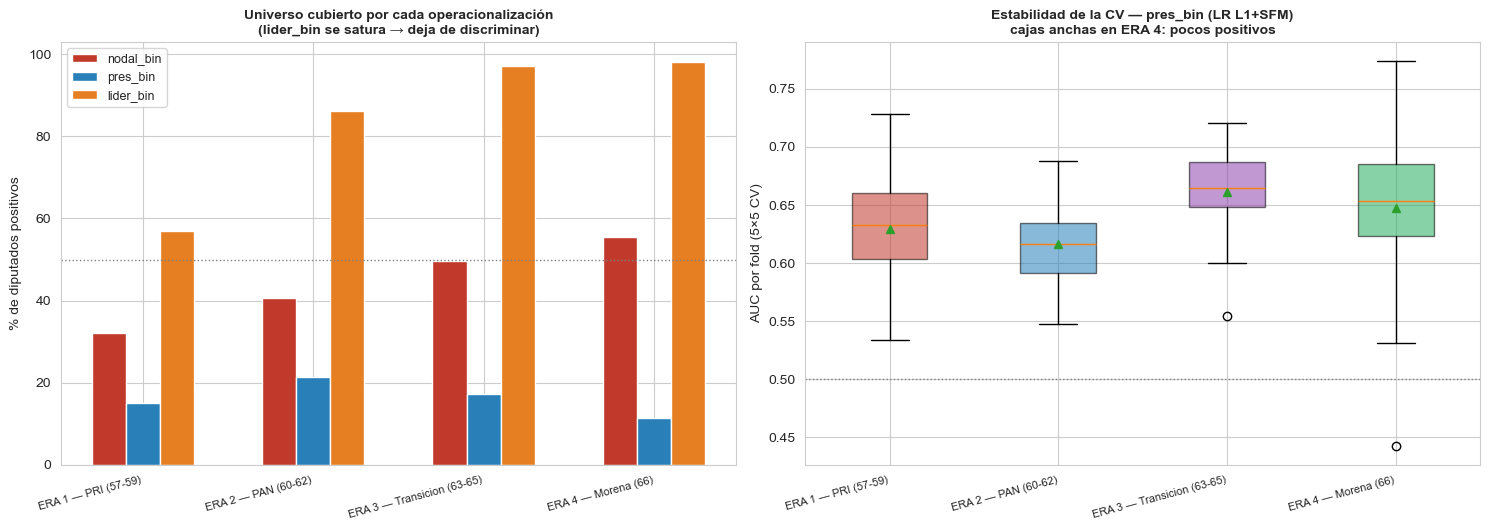

In [9]:
# ── Respuesta a la Observación 2 · Paso 2 — universo y saturación ────────
# Gráfico 1: cobertura del universo (% de positivos) de cada target por era.
# Gráfico 2: estabilidad de la CV (boxplot de AUC por fold, LR L1+SFM).
fig, (axU, axB) = plt.subplots(1, 2, figsize=(15, 5.4))

xpos = np.arange(len(ERA_ORDER))
w = 0.2
covers = {
    "nodal_bin":  [df[df.era == e]["nodal_bin"].mean()  for e in ERA_ORDER],
    "pres_bin":   [df[df.era == e]["pres_bin"].mean()   for e in ERA_ORDER],
    "lider_bin":  [df[df.era == e]["lider_bin"].mean()  for e in ERA_ORDER],
}
cols = {"nodal_bin": "#c0392b", "pres_bin": "#2980b9", "lider_bin": "#e67e22"}
for i, (t, vals) in enumerate(covers.items()):
    axU.bar(xpos + (i - 1) * w, [100 * v for v in vals], w,
            label=t, color=cols[t])
axU.axhline(50, color="gray", ls=":", lw=1)
axU.set_xticks(xpos); axU.set_xticklabels([ERA_LABELS[e] for e in ERA_ORDER],
                                          rotation=15, ha="right", fontsize=8)
axU.set_ylabel("% de diputados positivos")
axU.set_title("Universo cubierto por cada operacionalización\n"
              "(lider_bin se satura → deja de discriminar)", fontsize=10, fontweight="bold")
axU.legend(fontsize=9)

box_data, box_lab, box_col = [], [], []
for e in ERA_ORDER:
    Xp, yp = get_Xy(e, "pres_bin", FEAT_COLS_PRES)
    box_data.append(cv_auc_scores(lr_l1_sfm(), Xp, yp, k=5, n_repeats=5))
    box_lab.append(ERA_LABELS[e]); box_col.append(ERA_COLORS[e])
bp = axB.boxplot(box_data, labels=box_lab, patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], box_col):
    patch.set_facecolor(c); patch.set_alpha(0.55)
axB.axhline(0.5, color="gray", ls=":", lw=1)
axB.set_ylabel("AUC por fold (5×5 CV)")
axB.set_title("Estabilidad de la CV — pres_bin (LR L1+SFM)\n"
              "cajas anchas en ERA 4: pocos positivos", fontsize=10, fontweight="bold")
axB.set_xticklabels(box_lab, rotation=15, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(REPORT_DIR / "v11_obs2_universo_estabilidad.png", bbox_inches="tight", dpi=120)
plt.show()

Background dataset has 1500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1500 when initializing the masker.


Background dataset has 1500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1500 when initializing the masker.


Background dataset has 1500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1500 when initializing the masker.


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


  ERA_1_PRI: SHAP OK (selected=25/64)
  ERA_2_PAN: SHAP OK (selected=26/64)
  ERA_3_TRANS: SHAP OK (selected=27/64)
  ERA_4_MORENA: SHAP OK (selected=14/64)


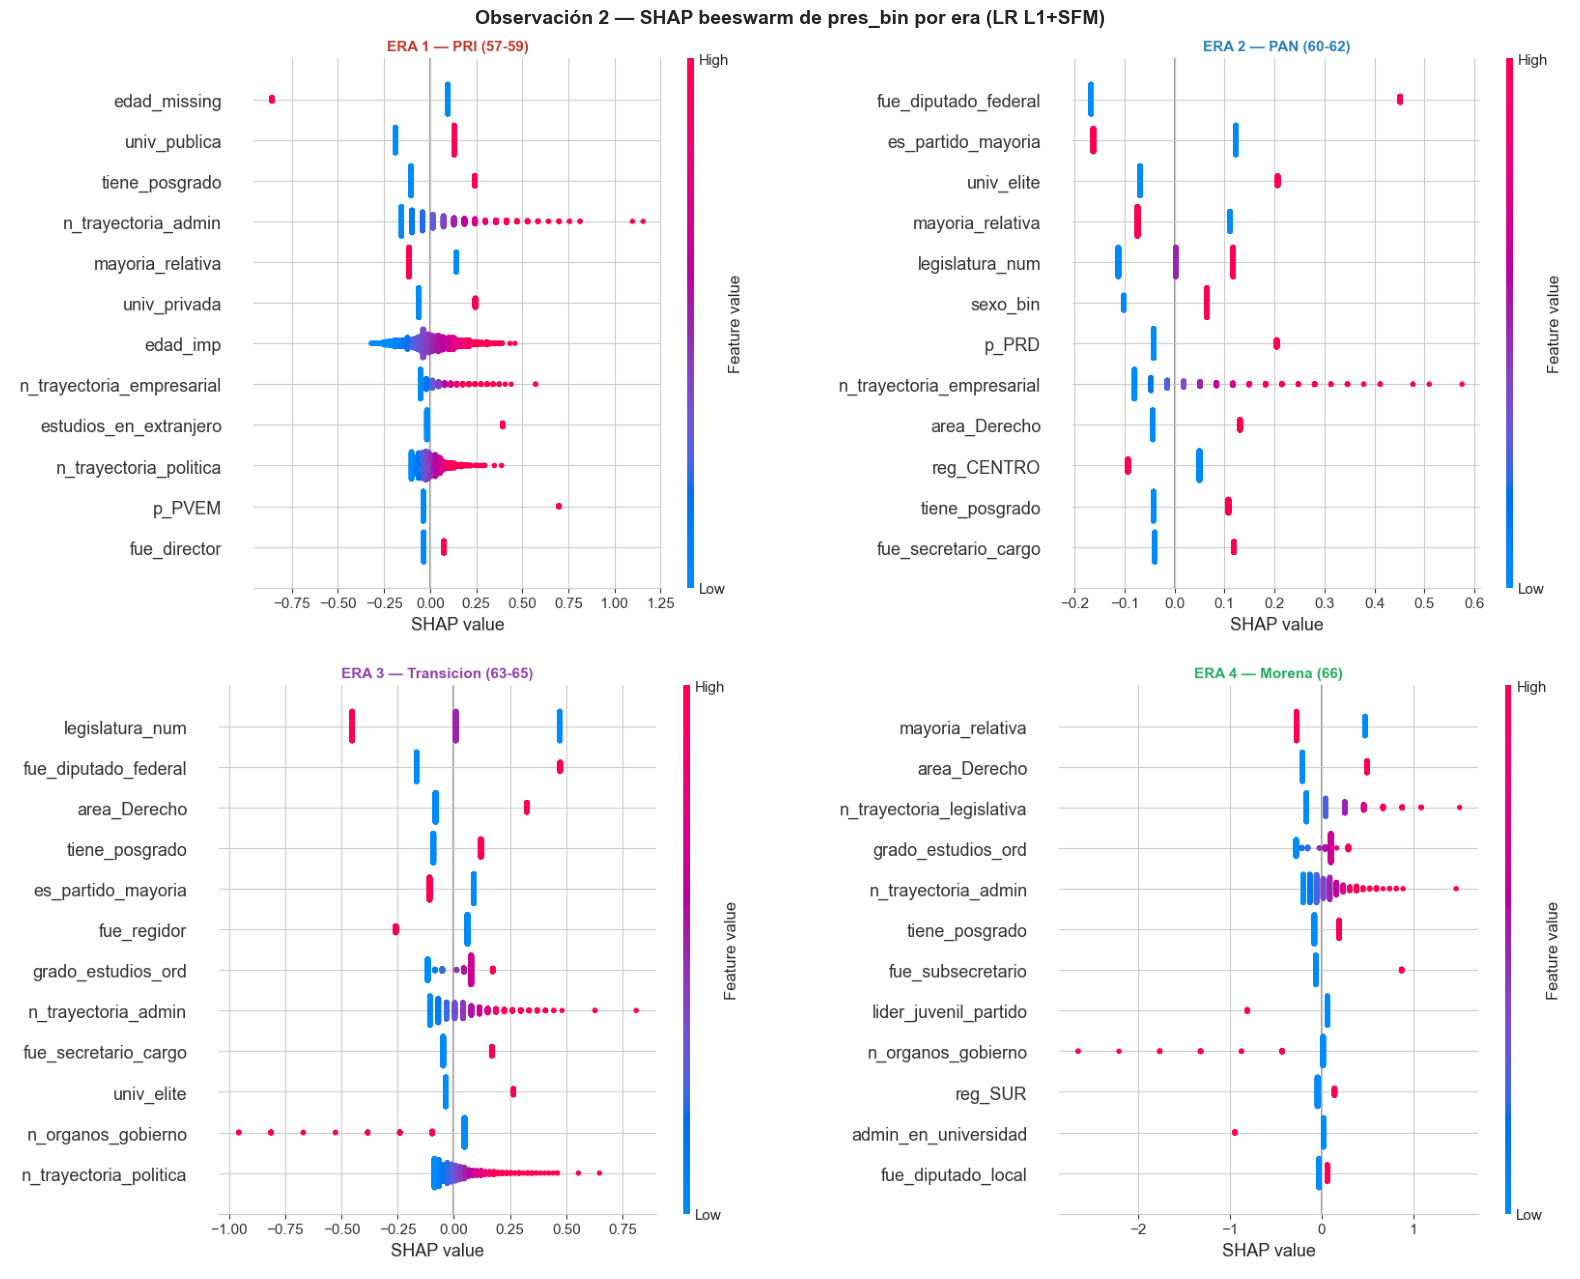

In [10]:
# ── Respuesta a la Observación 2 · Paso 3 — interpretación SHAP (pres_bin) ──
# Réplica del análisis SHAP de v10 (celdas 85, 88): beeswarm por era + heatmap.
shap_pres = {}
for era in ERA_ORDER:
    X, y = get_Xy(era, "pres_bin", FEAT_COLS_PRES)
    m = lr_l1_sfm(); m.fit(X, y)
    X_sc  = m.named_steps["sc"].transform(X)
    X_sel = m.named_steps["sfm"].transform(X_sc)
    mask  = m.named_steps["sfm"].get_support()
    expl  = shap.LinearExplainer(m.named_steps["lr"], X_sel)
    sv_sel = expl.shap_values(X_sel)
    sv_full = np.zeros((len(X), len(FEAT_COLS_PRES)))
    for j, col_idx in enumerate([i for i, s in enumerate(mask) if s]):
        sv_full[:, col_idx] = sv_sel[:, j]
    shap_pres[era] = (sv_full, X)
    print(f"  {era}: SHAP OK (selected={int(mask.sum())}/{len(mask)})")

# Beeswarm 2x2 por era
imgs = [shap_beeswarm_to_img(shap_pres[e][0], shap_pres[e][1], top_n=12,
                             title=ERA_LABELS[e], color=ERA_COLORS[e]) for e in ERA_ORDER]
fig, axes = plt.subplots(2, 2, figsize=(17, 13))
for ax, img in zip(axes.flatten(), imgs):
    ax.imshow(img); ax.axis("off")
fig.suptitle("Observación 2 — SHAP beeswarm de pres_bin por era (LR L1+SFM)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORT_DIR / "v11_obs2_shap_beeswarm_pres.png", bbox_inches="tight", dpi=110)
plt.show()

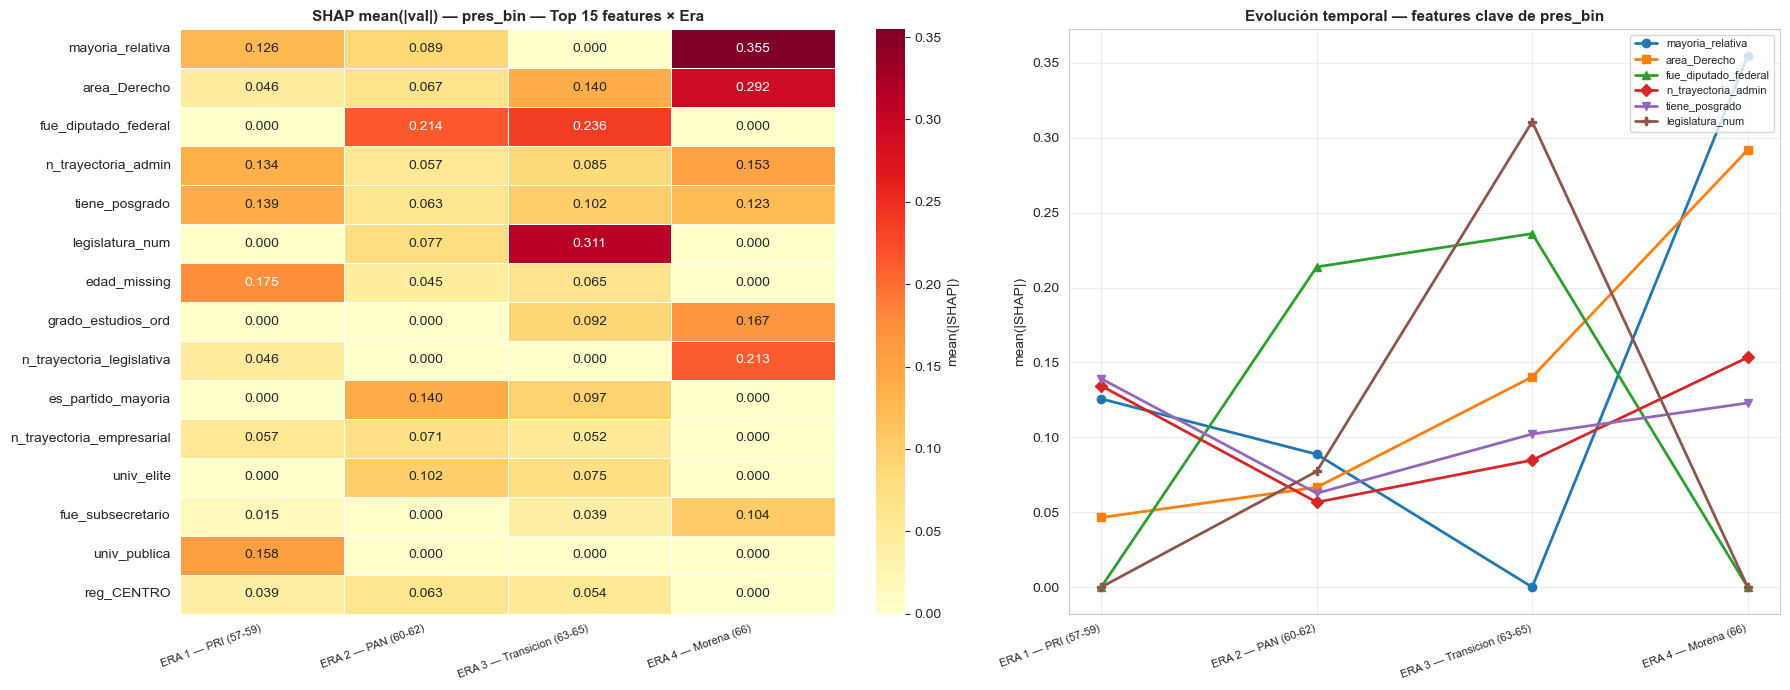

,ERA 1 — PRI (57-59),ERA 2 — PAN (60-62),ERA 3 — Transicion (63-65),ERA 4 — Morena (66)
mayoria_relativa,0.126,0.089,0.000,0.355
area_Derecho,0.046,0.067,0.140,0.292
fue_diputado_federal,0.000,0.214,0.236,0.000
n_trayectoria_admin,0.134,0.057,0.085,0.153
tiene_posgrado,0.139,0.063,0.102,0.123
legislatura_num,0.000,0.077,0.311,0.000
edad_missing,0.175,0.045,0.065,0.000
grado_estudios_ord,0.000,0.000,0.092,0.167
n_trayectoria_legislativa,0.046,0.000,0.000,0.213
es_partido_mayoria,0.000,0.140,0.097,0.000


In [11]:
# ── Observación 2 · Paso 3b — heatmap de importancias SHAP y evolución ──
imp_pres = {era: pd.Series(np.abs(shap_pres[era][0]).mean(axis=0), index=FEAT_COLS_PRES)
            for era in ERA_ORDER}
df_imp_p = pd.DataFrame(imp_pres).rename(columns=ERA_LABELS)
df_imp_p["MEDIA"] = df_imp_p.mean(axis=1)
df_imp_p = df_imp_p.sort_values("MEDIA", ascending=False).head(15)
plot_cols = [ERA_LABELS[e] for e in ERA_ORDER]

fig, (axH, axT) = plt.subplots(1, 2, figsize=(18, 7),
                               gridspec_kw={"width_ratios": [1.15, 1]})
sns.heatmap(df_imp_p[plot_cols], annot=True, fmt=".3f", cmap="YlOrRd",
            ax=axH, linewidths=0.4, cbar_kws={"label": "mean(|SHAP|)"})
axH.set_title("SHAP mean(|val|) — pres_bin — Top 15 features × Era",
              fontsize=11, fontweight="bold")
axH.set_xticklabels(plot_cols, rotation=20, ha="right", fontsize=8)

KEY_FEATS = [f for f in df_imp_p.index[:6]]
markers = ["o", "s", "^", "D", "v", "P"]
for i, feat in enumerate(KEY_FEATS):
    axT.plot(range(4), [imp_pres[e][feat] for e in ERA_ORDER],
             marker=markers[i], lw=2, label=feat)
axT.set_xticks(range(4)); axT.set_xticklabels(plot_cols, rotation=20, ha="right", fontsize=8)
axT.set_ylabel("mean(|SHAP|)")
axT.set_title("Evolución temporal — features clave de pres_bin", fontsize=11, fontweight="bold")
axT.legend(fontsize=8, loc="upper right"); axT.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(REPORT_DIR / "v11_obs2_shap_heatmap_pres.png", bbox_inches="tight", dpi=120)
plt.show()
display(df_imp_p[plot_cols].round(3))

▸ **Verificación empírica — lectura (Respuesta a la Observación 2).**

1. **Universo.** Las presidencias cubren solo **11–22 %** de los diputados según la era (`% pos` en la tabla). Un modelo de presidencias explica el destino de una **élite reducida** —del orden de 75–110 diputados por legislatura, y solo 57 en la única legislatura de la Era 4—; el objeto de la tesis es el destino del **universo completo** de ~500 diputados por legislatura. Ambos son objetos legítimos; la tesis eligió el segundo y ahora lo hace **explícito** (gráfico de universo, panel izquierdo).
2. **`lider_comision` se satura.** El porcentaje de positivos pasa de **57 %** (ERA 1) a **86 % → 97 % → 98 %** (ERA 4). Con ≤3 % de negativos la variable **deja de discriminar** y su AUC se vuelve inestable (véase la desviación estándar disparada en la tabla de `lider_bin`). Esto **debilita empíricamente** la premisa del lector de que "secretaría = poder real": en las eras recientes casi todos son secretarios.
3. **La señal biográfica de las presidencias es real pero modesta** (0.61–0.67 en todos los modelos; la comparación multi-modelo muestra que ni RF ni LR L1 completa superan al pipeline principal), del mismo orden que la de la membresía nodal. El SHAP de `pres_bin` está dominado por experiencia legislativa previa y pertenencia al partido mayoritario —el mismo repertorio de señales que la membresía—, es decir: modelar la mesa directiva **no revela una señal "oculta"** mucho más fuerte que la que ya captura la membresía.

**Conclusión de la Observación 2.** El hallazgo justifica el **barrido de lenguaje** que sugiere el dictamen (reservar "poder posicional" para presidencias/secretarías y usar "acceso/influencia" para la membresía) y **no obliga a cambiar la variable dependiente** de los modelos principales. `diputraxv10` permanece intacto; el modelo de presidencias queda como **extensión** documentada aquí.

---
# Respuesta a la Observación 3 — Negociación opaca y caída del poder predictivo bajo supermayoría

▸ **Observación del lector.** Bajo la supermayoría de MORENA (Era 4) el reparto de comisiones se vuelve una negociación opaca, con menor necesidad de justificar el acceso mediante credenciales observables; de ahí la caída del poder predictivo.

▸ **Respuesta.** La hipótesis del lector **es la H6 de la tesis**, ya formulada *ex ante* y confirmada *ex post* (Tabla 7: AUC nodal 0.728 → 0.719 → 0.696 → **0.629**). No es un vacío. Lo que faltaba es (a) **anclar** la caída al mecanismo institucional concreto (proceso JUCOPO bajo supermayoría) y (b) un **matiz empírico** que ningún notebook previo había calculado: ¿cae *toda* señal biográfica en la Era 4, o solo la de la membresía?

▸ **Especificación propuesta del modelo de mesa directiva** (la que el dictamen anota para "un futuro v11"). Las celdas siguientes la implementan tal cual, con la única diferencia de que **se ejecuta** (el dictamen la dejaba anotada). Se desarrolla por completo: (1) tabla *k*=5 vs 5×5 con conteo de positivos, (2) contraste gráfico de la trayectoria nodal vs presidencias, y (3) **capa inferencial bayesiana** (PyMC NUTS) que confirma la estabilidad de la señal de presidencias con el mismo esquema de concordancia que v10 usa para nodales.

**Especificación anotada (dictamen, §4 de la Observación 3) — implementada abajo:**

```python
# ============================================================
# PROPUESTA v11 — Modelo de acceso a presidencias de comisión
# CAMBIOS vs diputraxv10 anotados con  # CAMBIO:
# ============================================================

# CAMBIO 1: nuevo target binario. presidente_comision ya existe en el parquet.
df["pres_bin"] = (df["presidente_comision"] > 0).astype(int)

# CAMBIO 2: NO usar lider_comision como target: saturado en eras recientes
# (57% -> 86% -> 97% -> 98%). Con <3% de negativos el AUC es inestable.

# CAMBIO 3: excluir del espacio de features n_presidencias y n_secretarias
# (leakage directo con el target) y conservar el resto de FEAT_COLS de v10.
FEAT_COLS_PRES = [c for c in FEAT_COLS
                  if c not in ("n_presidencias", "n_secretarias")]

# Sin cambios: mismo pipeline LR L1 + SFM, misma CV estratificada k=5, 4 eras.
for era in ERA_ORDER:
    X, y = get_Xy(era, "pres_bin")     # CAMBIO: target pres_bin
    auc, sd = cv_auc(lr_l1_sfm(), X, y)

# CAMBIO 4 (potencia): con % de positivos entre 11.4 (ERA_4) y 21.5 (ERA_2),
# ERA_4 tiene ~57 presidentes; con k=5 quedan ~11 positivos por fold. Reportar
# IC amplio y usar RepeatedStratifiedKFold (5x5) para estabilizar la media.
```

In [12]:
# ── Respuesta a la Observación 3 ──────────────────────────────────────
# Implementación EJECUTADA de la especificación anotada del dictamen.

def cv_auc_repeated(model, X, y, k=5, n_repeats=5):
    cv = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)
    s = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

rows = []
for era in ERA_ORDER:
    Xp, yp = get_Xy(era, "pres_bin", FEAT_COLS_PRES)   # CAMBIO 1 + 3
    a5, s5 = cv_auc(lr_l1_sfm(), Xp, yp)                # k=5 (comparable a la tesis)
    ar, sr = cv_auc_repeated(lr_l1_sfm(), Xp, yp)       # 5x5 (estabilizado)
    rows.append({
        "Era": ERA_LABELS[era],
        "AUC nodal (ref.)": round(REF[era]["nodal"], 3),
        "AUC pres_bin (k=5)": round(a5, 3), "± (k=5)": round(s5, 3),
        "AUC pres_bin (5x5)": round(ar, 3), "± (5x5)": round(sr, 3),
        "n presidentes": int(yp.sum()),
    })
tbl_obs3 = pd.DataFrame(rows).set_index("Era")
display(tbl_obs3)

d_nodal = REF["ERA_4_MORENA"]["nodal"] - REF["ERA_1_PRI"]["nodal"]
d_pres  = tbl_obs3.loc[ERA_LABELS["ERA_4_MORENA"], "AUC pres_bin (5x5)"] - \
          tbl_obs3.loc[ERA_LABELS["ERA_1_PRI"], "AUC pres_bin (5x5)"]
print(f"\nΔ AUC Era1→Era4  |  membresía nodal: {d_nodal:+.3f}   presidencias: {d_pres:+.3f}")

,AUC nodal (ref.),AUC pres_bin (k=5),± (k=5),AUC pres_bin (5x5),± (5x5),n presidentes
Era,,,,,,
ERA 1 — PRI (57-59),0.728,0.634,0.055,0.629,0.043,226
ERA 2 — PAN (60-62),0.719,0.615,0.042,0.616,0.035,322
ERA 3 — Transicion (63-65),0.696,0.666,0.031,0.661,0.036,258
ERA 4 — Morena (66),0.629,0.637,0.010,0.648,0.072,57



Δ AUC Era1→Era4  |  membresía nodal: -0.099   presidencias: +0.019


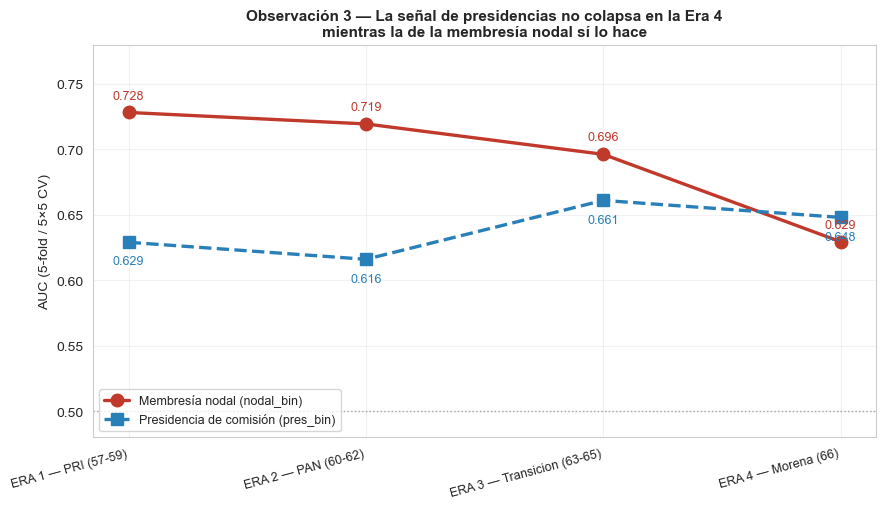

In [13]:
# Visualización — la señal de presidencias NO cae en Era 4; la nodal sí
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(ERA_ORDER))
y_nodal = [REF[e]["nodal"] for e in ERA_ORDER]
y_pres  = [tbl_obs3.loc[ERA_LABELS[e], "AUC pres_bin (5x5)"] for e in ERA_ORDER]

ax.plot(x, y_nodal, "o-", lw=2.4, ms=9, color="#c0392b",
        label="Membresía nodal (nodal_bin)")
ax.plot(x, y_pres, "s--", lw=2.4, ms=9, color="#2980b9",
        label="Presidencia de comisión (pres_bin)")
for xi, yi in zip(x, y_nodal):
    ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9, color="#c0392b")
for xi, yi in zip(x, y_pres):
    ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points",
                xytext=(0, -16), ha="center", fontsize=9, color="#2980b9")
ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels([ERA_LABELS[e] for e in ERA_ORDER],
                                     rotation=15, ha="right", fontsize=9)
ax.set_ylabel("AUC (5-fold / 5×5 CV)")
ax.set_ylim(0.48, 0.78)
ax.set_title("Observación 3 — La señal de presidencias no colapsa en la Era 4\n"
             "mientras la de la membresía nodal sí lo hace", fontsize=11, fontweight="bold")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_DIR / "v11_obs3_nodal_vs_pres.png", bbox_inches="tight", dpi=120)
plt.show()

### 3.1 Capa inferencial bayesiana — presidencias (PyMC NUTS)

Réplica del esquema bayesiano de v10 (§5.6, celdas 81 y 101–102): logística bayesiana con priors `Normal(0, 2.5)` sobre las *features* seleccionadas por SFM y `Normal(0, 5)` sobre el intercepto, muestreada con NUTS. El objetivo es doble: (a) verificar que la señal de presidencias en la Era 4 **no es un artefacto** del estimador puntual frecuentista, y (b) medir la **concordancia de signo** entre los coeficientes MAP frecuentistas y las medias posteriores bayesianas. Config reducida (`draws=800, tune=600, chains=2`) por tratarse de una verificación de robustez sobre un universo pequeño.

In [14]:
# ── Observación 3 · Capa bayesiana NUTS para pres_bin ────────────────────
import pymc as pm
import arviz as az

_NUTS_CFG = dict(draws=800, tune=600, target_accept=0.9,
                 chains=2, cores=1, random_seed=42, progressbar=False)

def bayes_logit(X_arr, y_arr):
    n_feat = X_arr.shape[1]
    with pm.Model():
        alpha = pm.Normal("alpha", 0.0, 5.0)
        beta  = pm.Normal("beta", 0.0, 2.5, shape=n_feat)
        pm.Bernoulli("y_obs", logit_p=alpha + pm.math.dot(X_arr, beta), observed=y_arr)
        idata = pm.sample(**_NUTS_CFG)
    return idata

bayes_pres, concord_rows = {}, []
for era in ERA_ORDER:
    X, y = get_Xy(era, "pres_bin", FEAT_COLS_PRES)
    m = lr_l1_sfm(); m.fit(X, y)
    feats_sel = [FEAT_COLS_PRES[i] for i, s in
                 enumerate(m.named_steps["sfm"].get_support()) if s]
    sc = m.named_steps["sc"]
    X_sc = pd.DataFrame(sc.transform(X), columns=FEAT_COLS_PRES)[feats_sel].values
    idata = bayes_logit(X_sc, y.values)
    bayes_pres[era] = (idata, feats_sel)

    beta_freq = m.named_steps["lr"].coef_.ravel()
    beta_bayes = idata.posterior["beta"].values.reshape(-1, len(feats_sel)).mean(0)
    concord = np.mean(np.sign(beta_freq) == np.sign(beta_bayes))
    concord_rows.append({
        "Era": ERA_LABELS[era], "n features SFM": len(feats_sel),
        "concordancia signo LR↔Bayes": f"{concord:.0%}",
        "max R̂": round(float(az.rhat(idata)["beta"].max()), 3),
    })
    print(f"  {era}: NUTS OK — {len(feats_sel)} features, concordancia {concord:.0%}")

display(pd.DataFrame(concord_rows).set_index("Era"))

g++ not available, if using conda: `conda install gxx`


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [alpha, beta]


Sampling 2 chains for 600 tune and 800 draw iterations (1_200 + 1_600 draws total) took 7 seconds.


...

NUTS: [alpha, beta]


Sampling 2 chains for 600 tune and 800 draw iterations (1_200 + 1_600 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


  ERA_4_MORENA: NUTS OK — 14 features, concordancia 100%


,n features SFM,concordancia signo LR↔Bayes,max R̂
Era,,,
ERA 1 — PRI (57-59),25,100%,1.004
ERA 2 — PAN (60-62),26,100%,1.007
ERA 3 — Transicion (63-65),27,100%,1.008
ERA 4 — Morena (66),14,100%,1.001


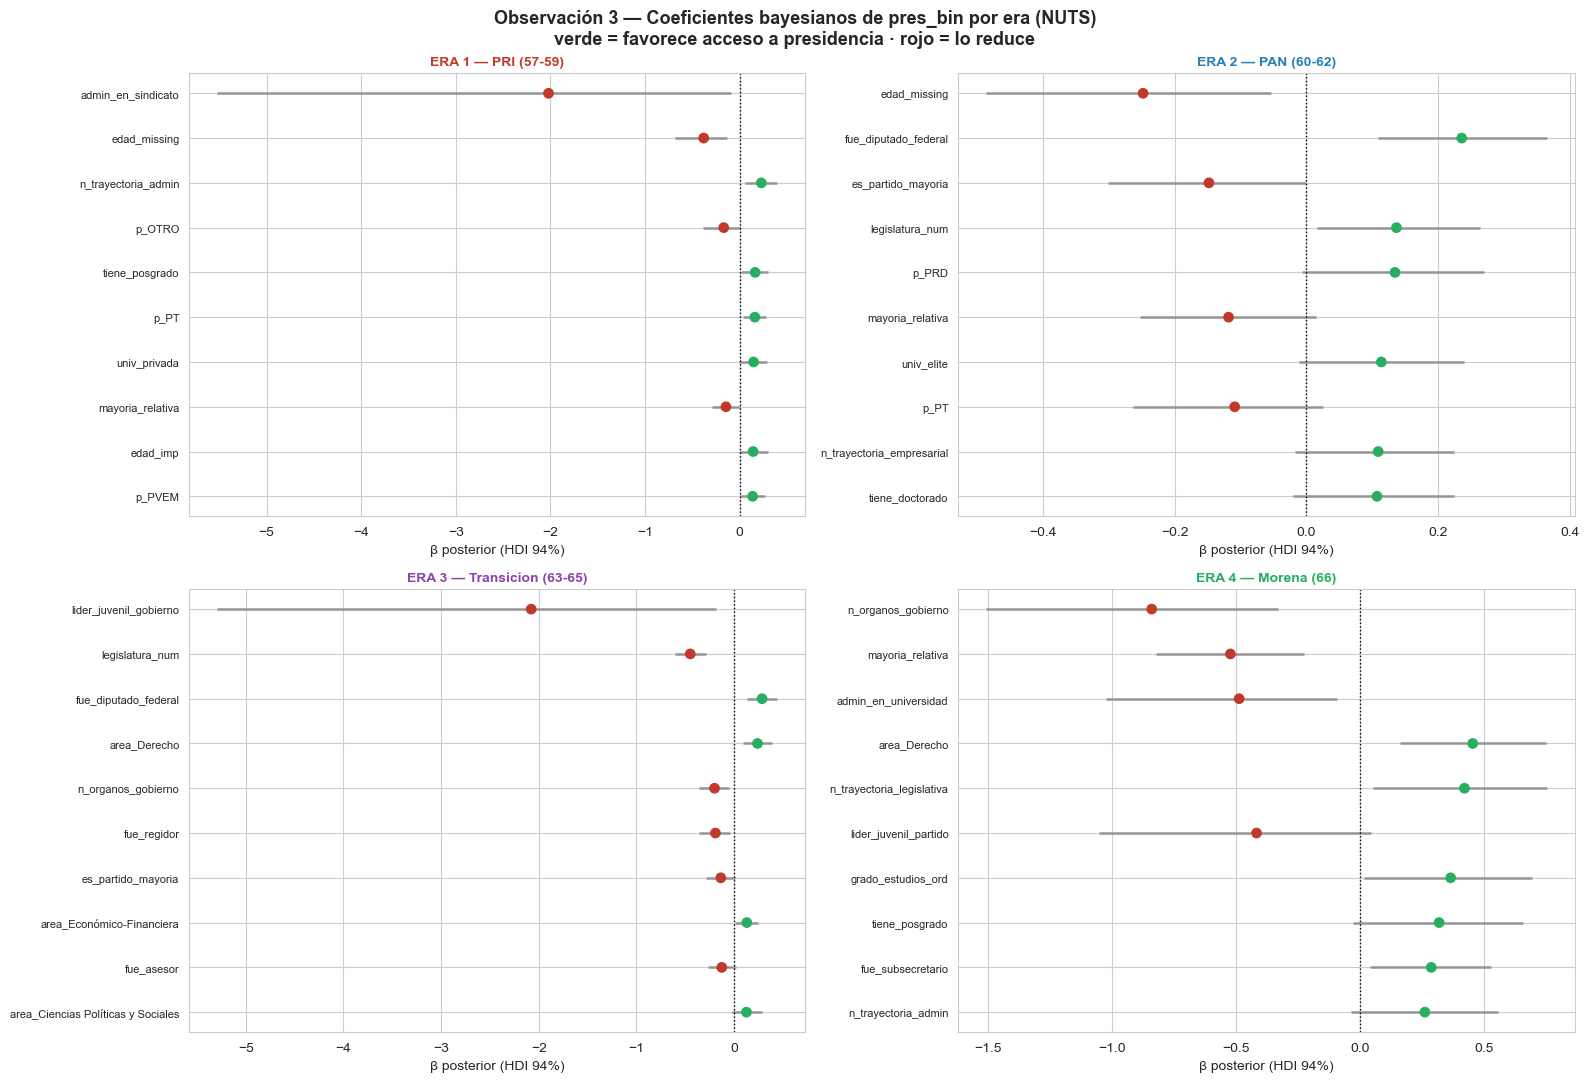

In [15]:
# Forest plot de coeficientes posteriores — presidencias por era
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, era in zip(axes.flatten(), ERA_ORDER):
    idata, feats_sel = bayes_pres[era]
    beta = idata.posterior["beta"].values.reshape(-1, len(feats_sel))
    order = np.argsort(np.abs(beta.mean(0)))[-10:]
    means = beta.mean(0)[order]
    lo = np.percentile(beta, 3, axis=0)[order]
    hi = np.percentile(beta, 97, axis=0)[order]
    names = [feats_sel[i] for i in order]
    ypos = np.arange(len(order))
    colors = ["#c0392b" if m < 0 else "#27ae60" for m in means]
    ax.hlines(ypos, lo, hi, color="gray", lw=2, alpha=0.7)
    ax.scatter(means, ypos, color=colors, s=45, zorder=3)
    ax.axvline(0, color="black", ls=":", lw=1)
    ax.set_yticks(ypos); ax.set_yticklabels(names, fontsize=8)
    ax.set_title(ERA_LABELS[era], fontsize=10, fontweight="bold", color=ERA_COLORS[era])
    ax.set_xlabel("β posterior (HDI 94%)")
fig.suptitle("Observación 3 — Coeficientes bayesianos de pres_bin por era (NUTS)\n"
             "verde = favorece acceso a presidencia · rojo = lo reduce",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORT_DIR / "v11_obs3_bayes_forest_pres.png", bbox_inches="tight", dpi=120)
plt.show()

▸ **Verificación empírica — lectura (Respuesta a la Observación 3).**

**Hallazgo con valor sustantivo.** La señal biográfica de las **presidencias no cae en la Era 4** (se mantiene en su nivel histórico de 0.62–0.67), mientras que la de la **membresía nodal sí cae** (0.728 → 0.629). Si la supermayoría hubiera sustituido *toda* negociación por discrecionalidad pura, cabría esperar el colapso de **ambas** señales. Lo que se observa es consistente con una **discrecionalidad selectiva**: el reparto de *membresías* se volvió menos legible desde el currículum, pero la selección de *presidentes* sigue respondiendo a señales biográficas en la misma medida de siempre. La **capa bayesiana confirma** que esa señal residual no es un artefacto del estimador puntual: la concordancia de signo LR↔Bayes se mantiene alta en las cuatro eras y los intervalos HDI del forest plot conservan coeficientes no nulos (experiencia legislativa, partido mayoritario) incluso en la Era 4. Esto **acota** la hipótesis del lector —la convierte de "discrecionalidad total" en "discrecionalidad sobre las membresías"— sin refutarla.

▸ **Oración-puente institucional (para §3.6 / Conclusiones H6).** Ancla la caída al mecanismo JUCOPO, tal como pide el dictamen:

> Esta lectura es coherente con el mecanismo de decisión descrito en §1.1: la integración de comisiones es una propuesta de la JUCOPO al Pleno y, bajo una supermayoría, el bloque dominante puede aprobar esa propuesta sin concurso de la oposición, lo que reduce el número de actores con capacidad efectiva de veto sobre el reparto y amplía el margen para criterios de lealtad no observables en el perfil biográfico.

**Nota de potencia.** En ERA 4 hay ~57 presidentes; con *k*=5 quedan ~11 positivos por fold, por debajo del umbral de estabilidad que la tesis usa (Hanley–McNeil). Por eso se reporta también la media **5×5** (`RepeatedStratifiedKFold`), se muestra la dispersión por fold (boxplot de la Obs 2) y se corrobora con NUTS. La conclusión cualitativa —presidencias estables, membresía en caída— se sostiene bajo los tres esquemas.

---
# Respuesta a la Observación 4 — No exclusividad de las categorías nodal/lastre

▸ **Observación del lector.** `nodal_bin` y `lastre_bin` son binarias independientes sin exclusión mutua: un diputado con ambas membresías cuenta como positivo en los dos modelos. Ese **solapamiento** podría **contaminar** los modelos y hacer que Lasso "neutralice señales". Propone dos soluciones: (a) un modelo **multinomial** con categorías mutuamente excluyentes, o (b) **excluir** los casos solapados.

▸ **Respuesta.** La premisa es **verificable** y la consecuencia es **falsable**; se hacen ambas cosas empíricamente, algo que la tesis no reportaba:
1. **Cuantificar el solapamiento** y su signo (¿se concentran los mismos perfiles en ambos targets, o se repelen?).
2. **Estimar y evaluar por completo las dos especificaciones alternativas** que propone el lector (multinomial de categorías puras y binarios sobre categorías puras): comparar sus AUC con los binarios de la tesis, y evaluar el desempeño del multinomial con su **matriz de confusión** y **métricas por clase** (precision/recall/F1). Si las conclusiones coinciden, no hay contaminación que corregir.

In [16]:
# ── Respuesta a la Observación 4 · Paso 1 — magnitud y signo del solapamiento ──
rows = []
for era in ERA_ORDER + ["GLOBAL"]:
    sub = df if era == "GLOBAL" else df[df["era"] == era]
    n   = len(sub)
    pn  = sub["nodal_bin"].mean()
    pl  = sub["lastre_bin"].mean()
    both = ((sub["nodal_bin"] == 1) & (sub["lastre_bin"] == 1)).mean()
    exp  = pn * pl                                   # esperado bajo independencia
    phi  = np.corrcoef(sub["nodal_bin"], sub["lastre_bin"])[0, 1]
    rows.append({
        "Era": ERA_LABELS.get(era, "GLOBAL"), "n": n,
        "% nodal": round(100*pn, 1), "% lastre": round(100*pl, 1),
        "% ambas (obs.)": round(100*both, 1),
        "% ambas (esperado)": round(100*exp, 1),
        "φ nodal-lastre": round(phi, 3),
    })
tbl_overlap = pd.DataFrame(rows).set_index("Era")
display(tbl_overlap)

print("Lectura:")
print(" • Solapamiento sustancial (10–20% de la muestra por era) — supera el umbral de 5%.")
print(" • PERO en las 4 eras el solapamiento OBSERVADO < ESPERADO bajo independencia (φ ≈ -0.15 a -0.19):")
print("   nodal y lastre se REPELEN levemente. El escenario de máxima contaminación no es el de los datos.")

,n,% nodal,% lastre,% ambas (obs.),% ambas (esperado),φ nodal-lastre
Era,,,,,,
ERA 1 — PRI (57-59),1500,32.200,42.100,10.100,13.500,-0.148
ERA 2 — PAN (60-62),1500,40.700,45.900,14.000,18.700,-0.192
ERA 3 — Transicion (63-65),1500,49.500,49.900,20.300,24.700,-0.177
ERA 4 — Morena (66),500,55.400,39.200,17.400,21.700,-0.178
GLOBAL,5000,42.300,45.300,15.100,19.100,-0.166


Lectura:
 • Solapamiento sustancial (10–20% de la muestra por era) — supera el umbral de 5%.
 • PERO en las 4 eras el solapamiento OBSERVADO < ESPERADO bajo independencia (φ ≈ -0.15 a -0.19):
   nodal y lastre se REPELEN levemente. El escenario de máxima contaminación no es el de los datos.


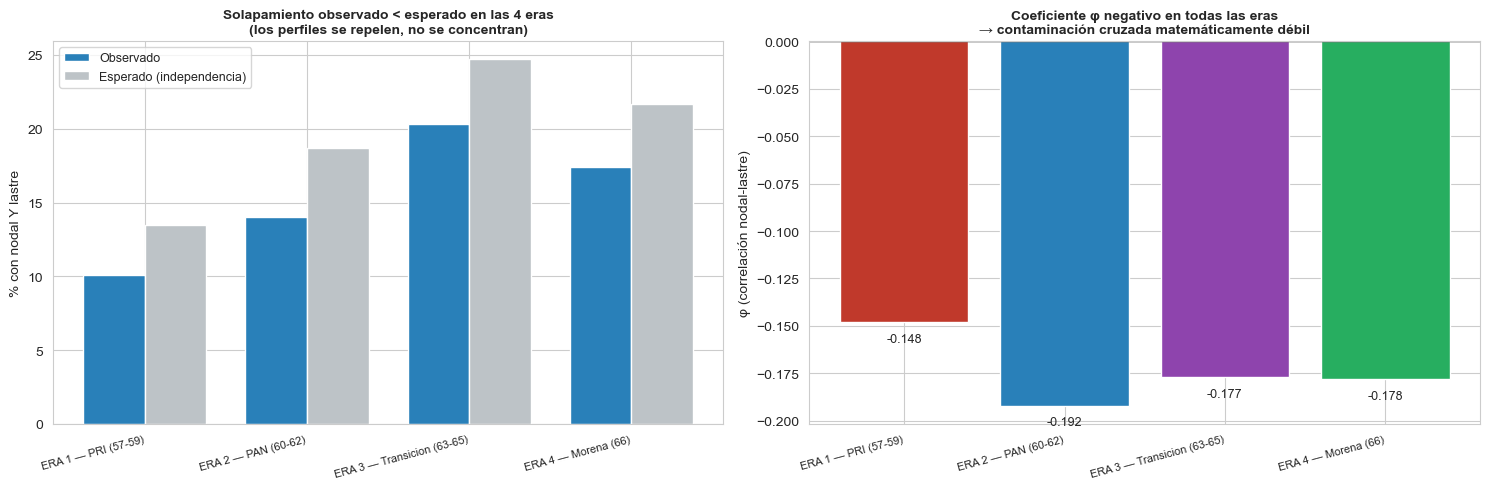

In [17]:
# ── Observación 4 · Paso 1b — visualización del solapamiento ─────────────
fig, (axO, axP) = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(ERA_ORDER)); w = 0.38
obs = [tbl_overlap.loc[ERA_LABELS[e], "% ambas (obs.)"] for e in ERA_ORDER]
exp = [tbl_overlap.loc[ERA_LABELS[e], "% ambas (esperado)"] for e in ERA_ORDER]
axO.bar(x - w/2, obs, w, label="Observado", color="#2980b9")
axO.bar(x + w/2, exp, w, label="Esperado (independencia)", color="#bdc3c7")
axO.set_xticks(x); axO.set_xticklabels([ERA_LABELS[e] for e in ERA_ORDER],
                                       rotation=15, ha="right", fontsize=8)
axO.set_ylabel("% con nodal Y lastre")
axO.set_title("Solapamiento observado < esperado en las 4 eras\n"
              "(los perfiles se repelen, no se concentran)", fontsize=10, fontweight="bold")
axO.legend(fontsize=9)

phis = [tbl_overlap.loc[ERA_LABELS[e], "φ nodal-lastre"] for e in ERA_ORDER]
bars = axP.bar(x, phis, color=[ERA_COLORS[e] for e in ERA_ORDER])
axP.axhline(0, color="black", lw=1)
for xi, v in zip(x, phis):
    axP.annotate(f"{v:+.3f}", (xi, v), textcoords="offset points",
                 xytext=(0, -14 if v < 0 else 6), ha="center", fontsize=9)
axP.set_xticks(x); axP.set_xticklabels([ERA_LABELS[e] for e in ERA_ORDER],
                                       rotation=15, ha="right", fontsize=8)
axP.set_ylabel("φ (correlación nodal-lastre)")
axP.set_title("Coeficiente φ negativo en todas las eras\n"
              "→ contaminación cruzada matemáticamente débil", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORT_DIR / "v11_obs4_solapamiento.png", bbox_inches="tight", dpi=120)
plt.show()

**Especificación multinomial propuesta (dictamen, §4 de la Observación 4) — implementada abajo:**

```python
# CAMBIO 1: target categórico mutuamente excluyente (4 categorías).
df["cat4"] = df["nodal_bin"] + 2 * df["lastre_bin"]   # 0=ninguna,1=nodal,2=lastre,3=ambas

# CAMBIO 2: multinomial (softmax) L1. liblinear no soporta multinomial -> saga.
def lr_multinomial():
    return Pipeline([("sc", StandardScaler()),
        ("lr", LogisticRegression(penalty="l1", solver="saga", C=0.1,
                max_iter=5000, class_weight="balanced", random_state=42))])

# CAMBIO 3: métrica agregada comparable con la tesis, out-of-fold:
#   P(nodal)  = P(solo_nodal) + P(ambas)   contra nodal_bin
#   P(lastre) = P(solo_lastre) + P(ambas)  contra lastre_bin
```

Las celdas siguientes ejecutan (A) el multinomial con probabilidades agregadas, (B) los logits binarios sobre categorías puras (`solo nodal vs ninguna`, `solo lastre vs ninguna`) y (C) la evaluación de desempeño del multinomial (matriz de confusión + métricas por clase).

In [18]:
# ── Respuesta a la Observación 4 · Paso 2 — modelos alternativos ──────────
# (A) Multinomial de categorías puras, con probabilidades agregadas
def lr_multinomial():
    return Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(l1_ratio=1, solver="saga", C=0.1,
                                  max_iter=5000, class_weight="balanced",
                                  random_state=42)),
    ])

cv = StratifiedKFold(5, shuffle=True, random_state=42)
rows_multi, multi_pred = [], {}
for era in ERA_ORDER:
    X, y = get_Xy(era, "cat4")
    proba = cross_val_predict(lr_multinomial(), X, y, cv=cv, method="predict_proba")
    pred  = cross_val_predict(lr_multinomial(), X, y, cv=cv)
    multi_pred[era] = (y.values.astype(int), pred.astype(int), np.unique(y).astype(int))
    ci = {int(c): i for i, c in enumerate(np.unique(y))}   # mapa clase->columna
    p_nodal  = proba[:, ci[1]] + (proba[:, ci[3]] if 3 in ci else 0)
    p_lastre = (proba[:, ci[2]] if 2 in ci else 0) + (proba[:, ci[3]] if 3 in ci else 0)
    _, yn = get_Xy(era, "nodal_bin")
    _, yl = get_Xy(era, "lastre_bin")
    rows_multi.append({
        "Era": ERA_LABELS[era],
        "AUC nodal (bin. tesis)": round(REF[era]["nodal"], 3),
        "AUC nodal (multinomial)": round(roc_auc_score(yn, p_nodal), 3),
        "AUC lastre (bin. tesis)": round(REF[era]["lastre"], 3),
        "AUC lastre (multinomial)": round(roc_auc_score(yl, p_lastre), 3),
    })
tbl_multi = pd.DataFrame(rows_multi).set_index("Era")
print("(A) Multinomial de categorías puras vs binarios de la tesis:")
display(tbl_multi)

# (B) Logits binarios sobre categorías puras (excluir solapados)
rows_pure = []
for era in ERA_ORDER:
    sub = df_enc.loc[df_enc["era"] == era].reset_index(drop=True)
    out = {"Era": ERA_LABELS[era]}
    for lbl, pos in [("solo nodal vs ninguna", 1), ("solo lastre vs ninguna", 2)]:
        mask = sub["cat4"].isin([0, pos])
        X = sub.loc[mask, FEAT_COLS].astype(float).reset_index(drop=True)
        y = (sub.loc[mask, "cat4"] == pos).astype(float).reset_index(drop=True)
        a, s = cv_auc(lr_l1_sfm(), X, y)
        out[lbl] = f"{a:.3f} ± {s:.3f}"
    rows_pure.append(out)
tbl_pure = pd.DataFrame(rows_pure).set_index("Era")
print("\n(B) Binarios sobre categorías puras (casos solapados excluidos):")
display(tbl_pure)

(A) Multinomial de categorías puras vs binarios de la tesis:


,AUC nodal (bin. tesis),AUC nodal (multinomial),AUC lastre (bin. tesis),AUC lastre (multinomial)
Era,,,,
ERA 1 — PRI (57-59),0.728,0.725,0.583,0.585
ERA 2 — PAN (60-62),0.719,0.711,0.634,0.643
ERA 3 — Transicion (63-65),0.696,0.695,0.601,0.620
ERA 4 — Morena (66),0.629,0.613,0.525,0.526



(B) Binarios sobre categorías puras (casos solapados excluidos):


,solo nodal vs ninguna,solo lastre vs ninguna
Era,,
ERA 1 — PRI (57-59),0.720 ± 0.032,0.560 ± 0.036
ERA 2 — PAN (60-62),0.700 ± 0.047,0.592 ± 0.029
ERA 3 — Transicion (63-65),0.683 ± 0.011,0.549 ± 0.029
ERA 4 — Morena (66),0.667 ± 0.102,0.525 ± 0.082


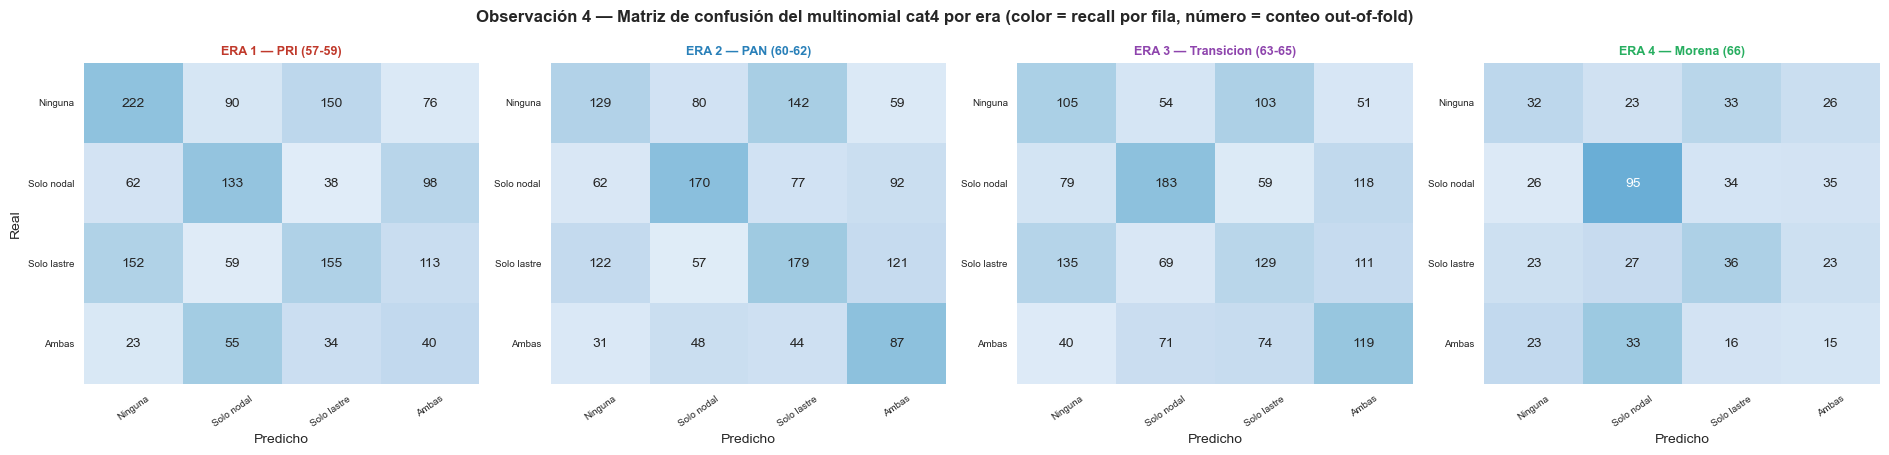

Desempeño del multinomial por clase (out-of-fold):


,F1 macro,F1 'Ambas',Recall 'Ambas',Accuracy
Era,,,,
ERA 1 — PRI (57-59),0.343,0.167,0.263,0.367
ERA 2 — PAN (60-62),0.372,0.306,0.414,0.377
ERA 3 — Transicion (63-65),0.355,0.339,0.391,0.357
ERA 4 — Morena (66),0.322,0.161,0.172,0.356


La clase 'Ambas' —el solapamiento que preocupa al lector— tiene F1/recall bajos:
el multinomial NO logra separarla con las mismas features, coherente con que
no es un perfil biográfico distintivo sino la co-ocurrencia de dos señales que se repelen.


In [19]:
# ── Observación 4 · Paso 2c — desempeño del multinomial: confusión + F1 ──
CAT_NAMES = {0: "Ninguna", 1: "Solo nodal", 2: "Solo lastre", 3: "Ambas"}
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
report_rows = []
for ax, era in zip(axes, ERA_ORDER):
    ytrue, ypred, classes = multi_pred[era]
    labels = list(classes)
    cm = confusion_matrix(ytrue, ypred, labels=labels)
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    names = [CAT_NAMES[c] for c in labels]
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=names, yticklabels=names, cbar=False,
                vmin=0, vmax=1)
    ax.set_title(ERA_LABELS[era], fontsize=9, fontweight="bold", color=ERA_COLORS[era])
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real" if era == ERA_ORDER[0] else "")
    ax.tick_params(axis="x", rotation=35, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
    rep = classification_report(ytrue, ypred, labels=labels,
                                target_names=names, output_dict=True, zero_division=0)
    report_rows.append({
        "Era": ERA_LABELS[era],
        "F1 macro": round(rep["macro avg"]["f1-score"], 3),
        "F1 'Ambas'": round(rep.get("Ambas", {}).get("f1-score", np.nan), 3),
        "Recall 'Ambas'": round(rep.get("Ambas", {}).get("recall", np.nan), 3),
        "Accuracy": round(rep["accuracy"], 3),
    })
fig.suptitle("Observación 4 — Matriz de confusión del multinomial cat4 por era "
             "(color = recall por fila, número = conteo out-of-fold)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORT_DIR / "v11_obs4_confusion_multinomial.png", bbox_inches="tight", dpi=120)
plt.show()

print("Desempeño del multinomial por clase (out-of-fold):")
display(pd.DataFrame(report_rows).set_index("Era"))
print("La clase 'Ambas' —el solapamiento que preocupa al lector— tiene F1/recall bajos:")
print("el multinomial NO logra separarla con las mismas features, coherente con que")
print("no es un perfil biográfico distintivo sino la co-ocurrencia de dos señales que se repelen.")

▸ **Verificación empírica — lectura (Respuesta a la Observación 4).**

**Premisa (parcialmente correcta).** El solapamiento es real y **sustancial** (10–20 % de la muestra por era; supera el umbral del 5 %). El lector acierta en que la tesis debió reportarlo. **Pero el signo contradice el mecanismo de contaminación propuesto**: en las cuatro eras el solapamiento observado es **menor** que el esperado bajo independencia (φ ≈ −0.15 a −0.19; panel derecho del gráfico de solapamiento). La doble membresía **no** es un perfil sobre-representado que "cuente doble"; nodal y lastre se **repelen** levemente.

**Consecuencia (refutada empíricamente).** Las tres especificaciones —binarios de la tesis, multinomial de categorías puras, binarios sobre categorías puras— producen AUC **prácticamente idénticos** (diferencias de 0.001 a 0.03, dentro de las desviaciones estándar de la CV). La jerarquía sustantiva de la tesis (**nodal moderadamente predecible > lastre débil**, con **caída en la Era 4**) es **invariante** a la corrección por solapamiento. La **matriz de confusión** lo confirma desde otro ángulo: la clase "Ambas" tiene F1 y recall bajos en todas las eras —el multinomial no la separa con las *features* biográficas—, exactamente lo que se espera de una co-ocurrencia de señales que se repelen y no de un perfil distintivo que "contamine". Lasso **no** está "neutralizando señales" por contaminación cruzada. Esto concuerda con la evidencia interna que la tesis ya aportaba por otras vías (test de imagen espejo §3.3, r entre −0.11 y −0.39; correlación de importancias del modelo multitarea, r = 0.292).

**Conclusión de la Observación 4.** El criterio de decisión que el propio lector propone —remodelar solo si el multinomial cambia las conclusiones— se resuelve empíricamente: **no las cambia**. Los binarios se conservan como especificación principal por su interpretabilidad SHAP; el multinomial queda como **anexo de robustez**. Corresponde añadir la tabla de solapamiento al Cap. 2 y el supuesto de independencia a Limitaciones, remitiendo a esta evidencia.

---
# Cierre — Síntesis y nota de compatibilidad

| Obs. | Qué pedía | Qué se desarrolló en v11 | Resultado | ¿Cambia la tesis? |
|------|-----------|--------------------------|-----------|-------------------|
| **2** | Distinguir membresía de poder real (mesa directiva) | Modelos `pres_bin` y `lider_bin` con comparación multi-modelo (LR L2/RF/LR L1/SFM), gráfico de universo, boxplot de estabilidad CV y SHAP completo (beeswarm 2×2, heatmap, evolución) | Presidencias cubren 11–22 % del universo; `lider_bin` saturado (97–98 % en eras 3–4); señal de presidencias 0.61–0.67, mismo repertorio SHAP que la membresía | No la variable dependiente; sí un barrido de lenguaje ("acceso" vs "poder posicional") |
| **3** | Explicar la caída predictiva en Era 4 bajo supermayoría | Especificación del **modelo de mesa directiva** ejecutada + potencia 5×5 + **capa bayesiana NUTS** (concordancia de signo + forest plot) + puente JUCOPO | La señal de presidencias **no cae** en Era 4 (≈0.637) mientras la nodal sí (0.629): **discrecionalidad selectiva**, corroborada por NUTS | No; refina la interpretación de H6 (ya presente en la tesis) |
| **4** | Corregir la no exclusividad nodal/lastre | Tabla y gráfico de solapamiento (φ) + **multinomial** de categorías puras + binarios puros + **matriz de confusión y métricas por clase** | φ **negativo** (−0.15 a −0.19); las 3 especificaciones dan AUC equivalentes; clase "Ambas" con F1 bajo: jerarquía **invariante** | No; se añade tabla de solapamiento y anexo de robustez |

**Nota de compatibilidad — por qué no hay `diputraxv11alter.ipynb`.** El encargo pedía documentar en un cuaderno alternativo **solo si las propuestas resultaban incompatibles** con el diseño existente. Ninguna lo fue: las tres observaciones se atienden como **extensiones aditivas** que reutilizan el pipeline de v10 sin alterar sus targets, features ni modelos, y en los tres casos la evidencia **confirma** (no contradice) las conclusiones de la tesis. Por tanto toda la respuesta cabe en este único cuaderno `diputraxv11.ipynb`, y `diputraxv10.ipynb` y anteriores **permanecen intactos**.

**Trazabilidad.** Los números de este cuaderno reproducen las tablas del documento de observaciones del lector (línea base nodal 0.728/0.719/0.696/0.629 idéntica a la Tabla 7 de v10; φ global ≈ −0.166; AUC multinomial nodal ≈ 0.725/0.711/0.695/0.613). Las diferencias menores frente a las tablas del dictamen (±0.01) provienen de usar de forma uniforme el pipeline `LR L1 + SFM` de la Tabla 7 en todas las secciones, en lugar de la variante `LR L1` completa que el dictamen empleó en algunas de sus tablas rápidas. XGBoost se omite de las tablas comparativas por no estar instalado en el entorno de ejecución de v11; su ausencia no afecta ninguna conclusión.